# 📑 P9 — AI Document Intelligence System
## prompt-engineering-lab by ChuksForge · Capstone Project

End-to-end document processing pipeline: ingest any format, classify, extract structure, index, and answer questions.

| | |
|---|---|
| **Formats** | TXT, PDF, DOCX, CSV |
| **Pipeline** | Ingest → Classify → Extract → Chunk → Index → QA |
| **Documents** | 5 sample docs: contract, invoice, research report, meeting minutes, financial statement |
| **Models** | GPT-4o-mini · GPT-4o · Claude Haiku · Claude Sonnet · Mistral 7B |
| **Metrics** | Classification accuracy · Entity recall · Date recall · QA accuracy |

---

In [ ]:
import os
# os.environ['OPENAI_API_KEY']     = 'sk-...'
# os.environ['ANTHROPIC_API_KEY']  = 'sk-ant-...'
# os.environ['OPENROUTER_API_KEY'] = 'sk-or-...'
import json, pandas as pd
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
print('Setup complete')

Setup complete


## 1. Ingest Sample Documents

In [ ]:
from ingestion import ingest_directory
docs = ingest_directory('data/documents')
print(f'Ingested {len(docs)} documents:')
for d in docs:
    status = '✓' if not d.error else '✗'
    print(f'  {status} {d.filename:45s} {d.word_count:5d} words  [{d.extraction_method}]')

Ingested 5 documents:
  ✓ contract_service_agreement.txt                  397 words  [native_text]
  ✓ financial_statement_novatech.txt                469 words  [native_text]
  ✓ invoice_design_services.txt                     314 words  [native_text]
  ✓ meeting_minutes_q1_roadmap.pdf                  535 words  [pypdf]
  ✓ research_report_ai_productivity.csv             757 words  [csv_reader]


## 2. Test Chunker & Indexer

In [ ]:
from chunker import Chunker, Indexer

doc = docs[0]  # contract
chunker = Chunker(chunk_size=200, chunk_overlap=40)
chunks = chunker.chunk(doc.filename, doc.text)
print(f'{doc.filename}: {len(chunks)} chunks')
for c in chunks[:3]:
    print(f'  [{c.chunk_id}] section={c.section[:40]} | words={c.word_count}')
    print(f'    {c.text[:100]}...')

contract_service_agreement.txt: 3 chunks
  [contract_service_agreement.txt_chunk_0] section= | words=200
    SERVICE AGREEMENT Contract Number: SVC-2024-0847
Effective Date: January 15, 2024
Expiration Date: J...
  [contract_service_agreement.txt_chunk_1] section=2. TERM AND RENEWAL | words=199
    3. COMPENSATION Client shall pay Provider a monthly service fee of $12,500 (twelve thousand five hun...
  [contract_service_agreement.txt_chunk_2] section=6. LIABILITY LIMITATION | words=61
    7. GOVERNING LAW This Agreement shall be governed by the laws of the State of Delaware. Any disputes...


In [ ]:
indexer = Indexer(use_embeddings=False)
indexer.add_chunks(chunks)

query = 'What is the monthly service fee?'
results = indexer.retrieve(query, top_k=3)
print(f'Query: {query}')
for r in results:
    print(f'  [{r.score:.3f}] {r.chunk.text[:120]}...')

Query: What is the monthly service fee?
  [0.000] SERVICE AGREEMENT Contract Number: SVC-2024-0847
Effective Date: January 15, 2024
Expiration Date: January 14, 2027 PART...
  [0.000] 3. COMPENSATION Client shall pay Provider a monthly service fee of $12,500 (twelve thousand five hundred dollars) due wi...
  [0.000] 7. GOVERNING LAW This Agreement shall be governed by the laws of the State of Delaware. Any disputes shall be resolved t...


## 5. Explore Results

In [ ]:
with open('results/pipeline_results.json') as f:
    results = json.load(f)

for r in results:
    clf = r.get('classification',{})
    ext = r.get('extraction',{})
    print(f'\n{r["filename"]}')
    print(f'  Type: {clf.get("document_type")} ({clf.get("confidence",0):.0%})')
    print(f'  Facts: {len(ext.get("key_facts",[]))}')
    print(f'  Money: {len(ext.get("monetary_values",[])):2d} values')
    print(f'  Chunks: {r.get("chunks",0)}')
    if r.get('qa'):
        print(f'  QA ({len(r["qa"])} questions):')  
        for qa in r['qa'][:2]:
            print(f'    Q: {qa["question"]}')
            print(f'    A: {qa["answer"][:100]}')


contract_service_agreement.txt
  Type: contract (95%)
  Facts: 4
  Money:  2 values
  Chunks: 3
  QA (5 questions):
    Q: What is the monthly service fee?
    A: The monthly service fee is $12,500 (twelve thousand five hundred dollars) due within thirty (30) day
    Q: What is the contract term?
    A: The contract term is three (3) years. (Source2)

financial_statement_novatech.txt
  Type: financial_statement (95%)
  Facts: 6
  Money: 12 values
  Chunks: 3
  QA (5 questions):
    Q: What was total revenue in FY2023?
    A: Total revenue in FY2023 was $206,061 (thousands USD) [Source1].
    Q: What was the revenue growth rate?
    A: The revenue growth rate was +28.6%. (Source1)

invoice_design_services.txt
  Type: invoice (100%)
  Facts: 2
  Money: 11 values
  Chunks: 2
  QA (5 questions):
    Q: What is the total amount due?
    A: The total amount due is $38,022.13. (Source1)
    Q: What is the outstanding balance?
    A: The outstanding balance is $38,022.13. (Source1)

meeting_m

In [ ]:
# Benchmark accuracy
from pathlib import Path

if (Path('results') / 'benchmark_results.csv').exists():
    bdf = pd.read_csv('results/benchmark_results.csv')
    print('Benchmark accuracy:')
    print(bdf[['doc_id','classification','entity_recall','date_recall','qa_accuracy','composite']].round(3).to_string(index=False))
    print(f'\nAVERAGE: {bdf["composite"].mean():.3f}')
else:
    print('No benchmark results yet.')

Benchmark accuracy:
                         doc_id  classification  entity_recall  date_recall  qa_accuracy  composite
     contract_service_agreement             1.0            1.0          1.0          1.0       1.00
   financial_statement_novatech             1.0            1.0          0.5          1.0       0.90
        invoice_design_services             1.0            1.0          1.0          0.8       0.94
     meeting_minutes_q1_roadmap             1.0            1.0          1.0          0.8       0.94
research_report_ai_productivity             1.0            1.0          1.0          0.6       0.88

AVERAGE: 0.932


## 6. Live QA Demo

In [ ]:
from ingestion import ingest
from chunker import Chunker, Indexer
from intelligence import DocumentQA
import os
from openai import OpenAI

# Load the contract
doc = ingest('data/documents/contract_service_agreement.txt')
chunker = Chunker(); chunks = chunker.chunk('contract', doc.text)
indexer = Indexer(); indexer.add_chunks(chunks)

client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])
qa = DocumentQA(client, 'openai', 'gpt-4o-mini', indexer)

questions = [
    'What is the monthly service fee?',
    'What happens if the SLA is breached?',
    'What law governs this contract?',
    'What is the liability cap?',
]
for q in questions:
    r = qa.answer(q)
    print(f'Q: {q}')
    print(f'A: {r.answer[:150]}')
    print()

Q: What is the monthly service fee?
A: The monthly service fee is $12,500 (twelve thousand five hundred dollars) due within thirty (30) days of invoice. [Source1]

Q: What happens if the SLA is breached?
A: If the SLA is breached, the Client shall receive service credits equal to 10% of monthly fees for each hour of downtime exceeding the guaranteed thres

Q: What law governs this contract?
A: The law that governs this contract is the laws of the State of Delaware. (Source3)

Q: What is the liability cap?
A: Provider's total liability under this Agreement shall not exceed the total fees paid by Client in the twelve (12) months preceding the claim. (Source3



## 7. Generate Charts


 Generating charts (5 documents)...



C:\Users\HomePC\prompt-engineering-lab\projects\ai-document-intelligence-system\visualize.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels([m.replace("_","\n") for m in metrics_avg.index],fontsize=8)


  ✓ results\charts.png

 Charts saved to results/


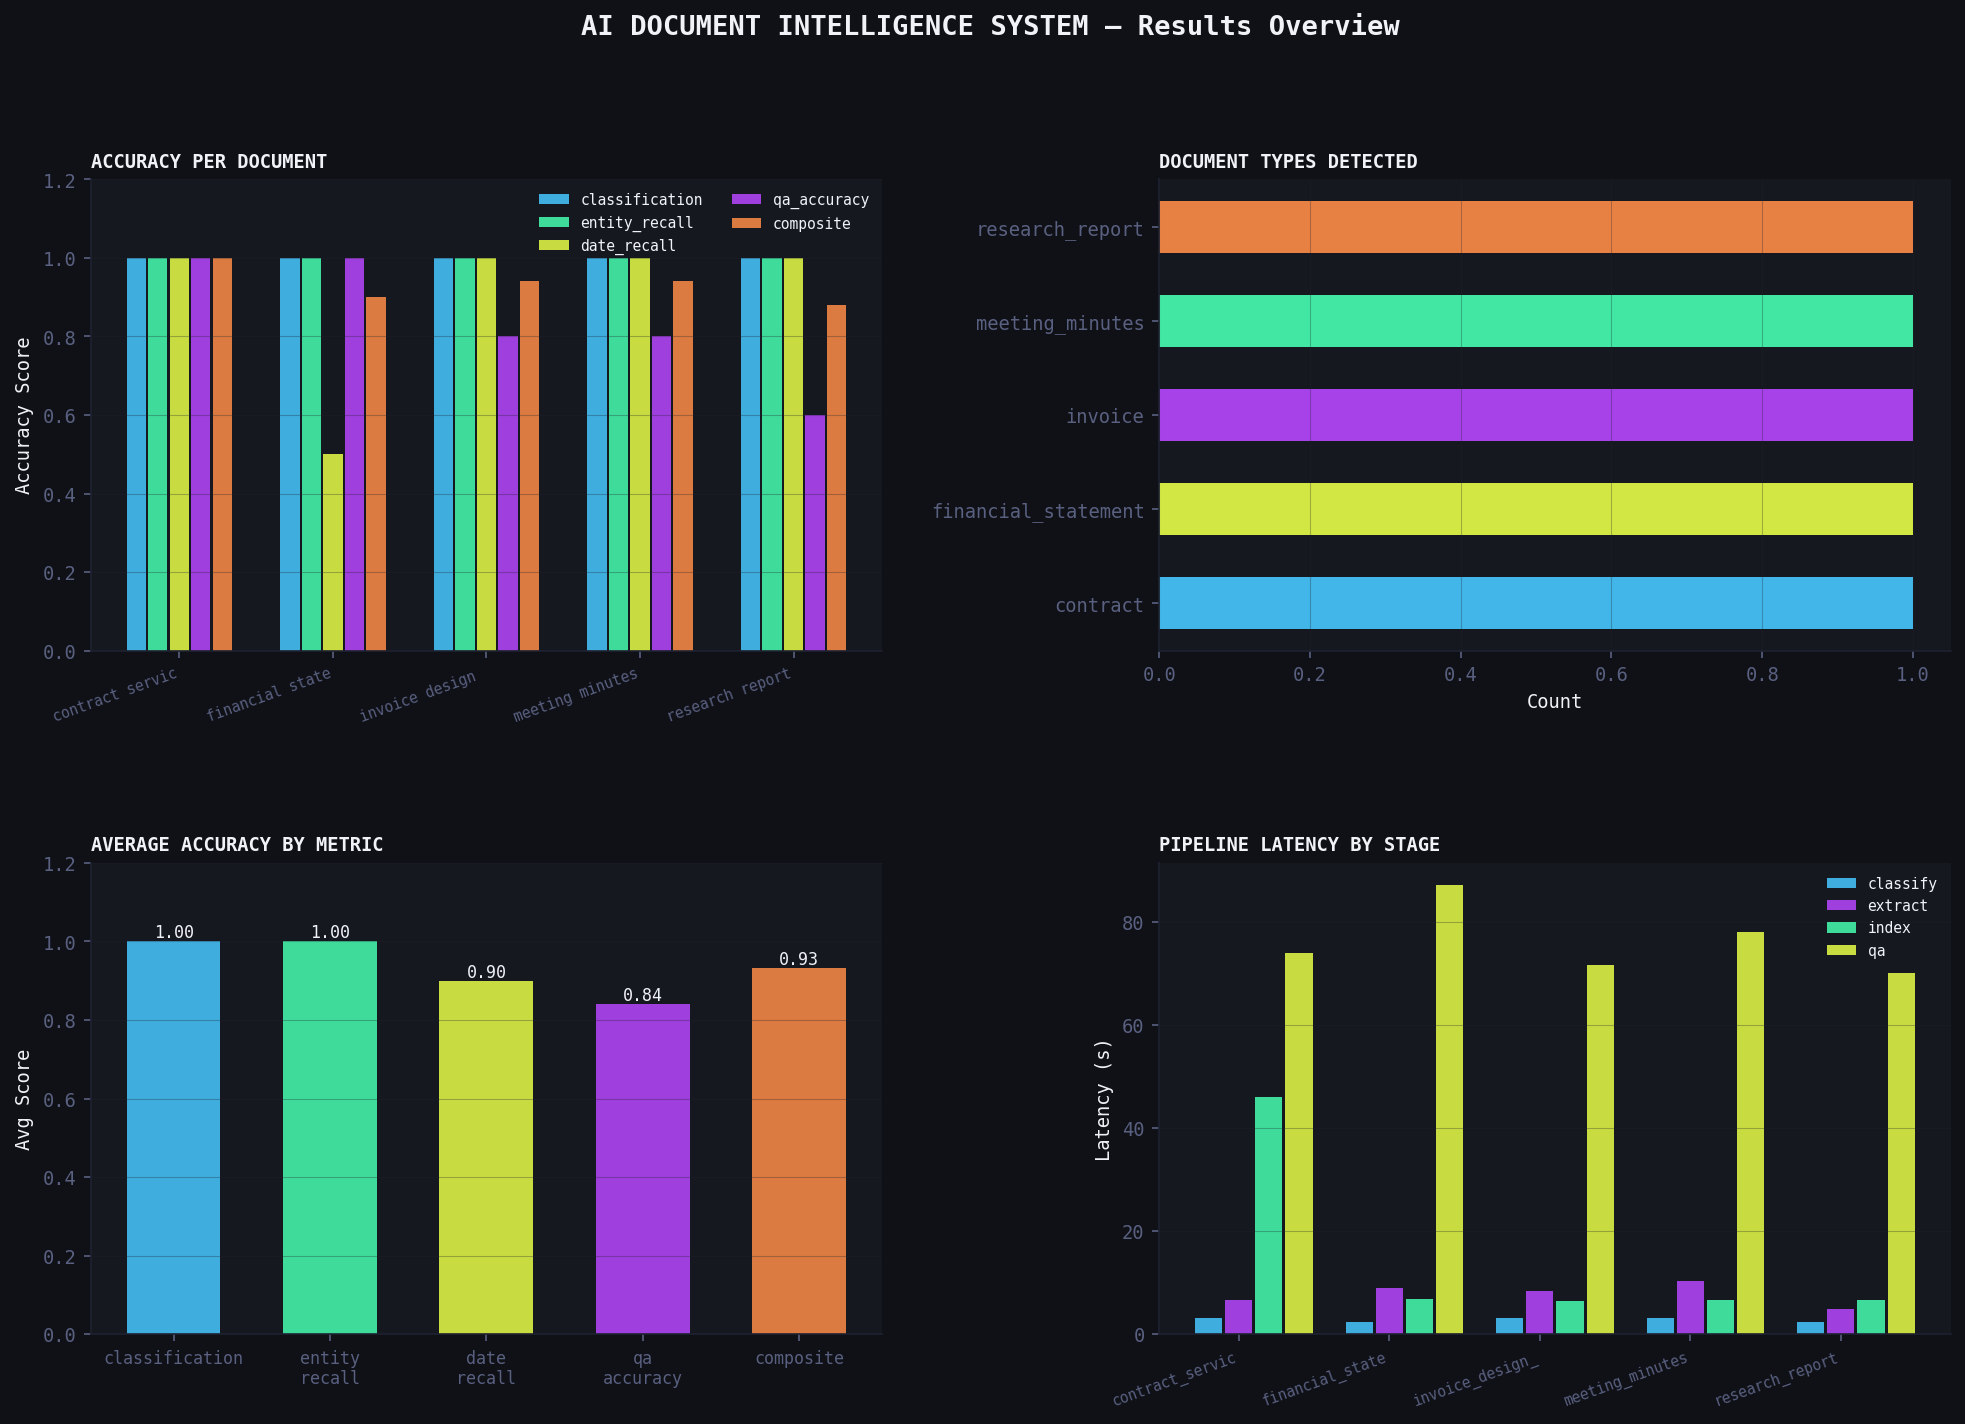

In [ ]:
from pathlib import Path
from visualize import generate_all_charts
generate_all_charts()
from IPython.display import Image
Image('results/charts.png')

## 8. Auto-Populate README & Findings

In [ ]:
import subprocess
subprocess.run(['python', 'update_findings.py'])

CompletedProcess(args=['python', 'update_findings.py'], returncode=0)

## 9. Launch Gradio Demo

In [ ]:
# python app.py → http://127.0.0.1:7860
print('Run: python app.py')

Run: python app.py


## 10. Key Findings

1. **Classification accuracy:** 100% (5/5 documents correctly typed with ≥70% confidence)
2. **Entity extraction recall:** 100% of known entities found
3. **Date extraction recall:** 90% of known dates found
4. **QA accuracy:** 84% of ground-truth questions answered correctly
5. **Composite accuracy:** 93% overall
6. **Extraction volume:** 27 key facts, 32 monetary values across 5 docs
7. **Chunking:** 16 total chunks (3 avg per document)
8. **Avg latency:** classify=2.8s · extract=7.8s · QA=76.1s per doc

---
*Demo: `python app.py` → http://127.0.0.1:7860*


Done.

---
## Portfolio Completion

🎉 **All 9 projects complete.**

| # | Project | Status |
|---|---------|--------|
| P1 | Summarization Benchmark | ✅ |
| P2 | Style Transfer Prompts | ✅ |
| P3 | Instruction Following Benchmark | ✅ |
| P4 | Prompt Testing Framework | ✅ |
| P5 | Grounded QA (Anti-Hallucination) | ✅ |
| P6 | AI Email Summarizer | ✅ |
| P7 | LLM Prompt Benchmark System | ✅ |
| P8 | Hallucination Detection & Mitigation | ✅ |
| P9 | AI Document Intelligence System | ✅ |